# 02 — KPI Analysis (SQL)

This notebook explores key credit risk and portfolio performance metrics using accepted LendingClub loans with **final outcomes only** (Fully Paid, Charged Off, Default).

The objective is to:
- Understand **portfolio-level risk**
- Analyse **risk segmentation** (grade, sub-grade, income, FICO, purpose)
- Evaluate **simple return / profit proxies**
- Build intuition for how lenders think about **risk vs return**

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DB_PATH = Path("credit_risk.db")
SQL_PATH = Path("sql/kpi_queries.sql")

In [2]:
def parse_sql_file(sql_path: Path):
    content = sql_path.read_text(encoding="utf-8").splitlines()

    queries = []
    comments = []
    sql_lines = []

    def flush():
        nonlocal comments, sql_lines
        if sql_lines:
            queries.append({
                "title": " ".join(comments).strip(),
                "query": "\n".join(sql_lines).strip()
            })
        comments, sql_lines = [], []

    for line in content:
        stripped = line.strip()

        if not stripped:
            continue

        if stripped.startswith("--") and not sql_lines:
            comments.append(stripped[2:].strip())
            continue

        if "--" in line:
            line = line.split("--", 1)[0].rstrip()

        sql_lines.append(line)

        if stripped.endswith(";"):
            flush()

    if sql_lines:
        flush()

    return queries


In [3]:
queries = parse_sql_file(SQL_PATH)
print(f"Loaded {len(queries)} queries from {SQL_PATH}")

with sqlite3.connect(DB_PATH) as conn:
    results = []
    for i, q in enumerate(queries, 1):
        df = pd.read_sql_query(q["query"], conn)
        title = q["title"] or f"Query {i}"
        results.append({"i": i, "title": title, "df": df})


Loaded 11 queries from sql/kpi_queries.sql


In [4]:
for r in results:
    print(f"\nKPI {r['i']}: {r['title']}")
    display(r["df"])


KPI 1: Uses clean_loans (accepted loans with final outcomes only) 1) Dataset size + class balance


,n_loans,n_default,default_rate_pct
0,1345350,268599,19.96



KPI 2: 2) Basic lending metrics


,avg_loan_amount,avg_funded_amount,avg_interest_rate_pct,avg_annual_income,avg_dti,avg_fico
0,14419.97,14411.55,13.24,76247.57,18.28,698.0



KPI 3: 3) Default rate by grade (risk segmentation)


...

,n,avg_net_cash_profit,total_net_cash_profit,net_profit_pct_of_funded
0,1345350,412.12,5.544403e+08,2.86



KPI 10: 10) Net cash profit by grade (risk-adjusted contribution)


,grade,n,default_rate_pct,avg_net_cash_profit,total_net_cash_profit,avg_profit_pct
0,A,235095,6.04,749.16,1.761232e+08,5.26
1,B,392748,13.39,696.19,2.734286e+08,5.38
2,C,381694,22.44,392.30,1.497395e+08,3.13
3,D,200966,30.39,80.16,1.610862e+07,1.28
4,E,93656,38.48,-222.04,-2.079531e+07,-0.83
5,F,32059,45.20,-743.02,-2.382061e+07,-3.02
6,G,9132,49.93,-1789.72,-1.634370e+07,-8.85



KPI 11: 11) Interest margin proxy (interest + late fees - principal loss net recoveries)


,n,avg_interest_plus_late,avg_principal_loss_net_recoveries,avg_net_margin_proxy
0,1345350,2400.56,1988.45,412.12


## Visuals

The following charts are generated from the KPI tables.

In [5]:
def bar_plot(df, x, y, title, xlabel=None, ylabel=None, rotate_x=False):
    plt.figure()
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

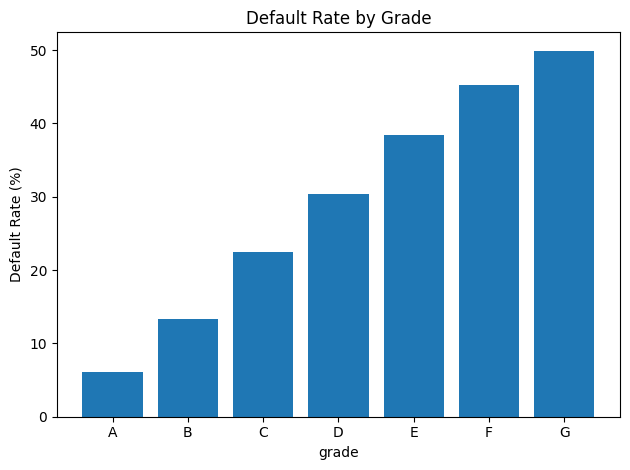

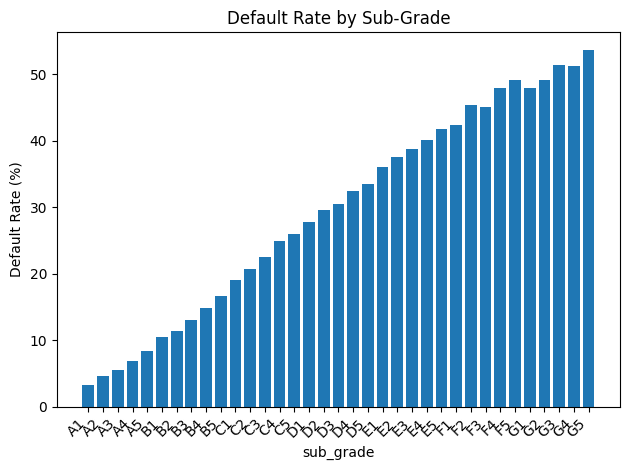

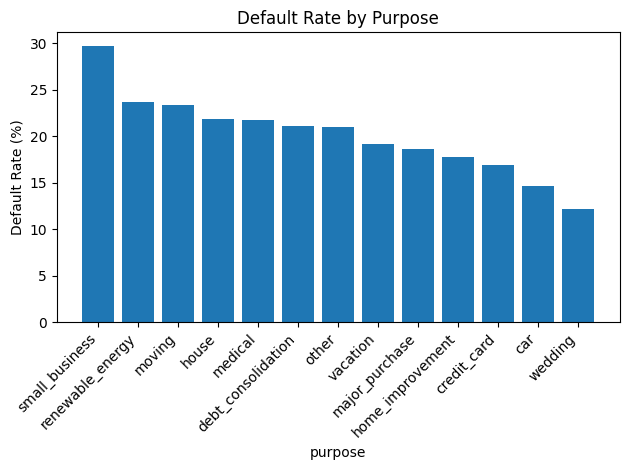

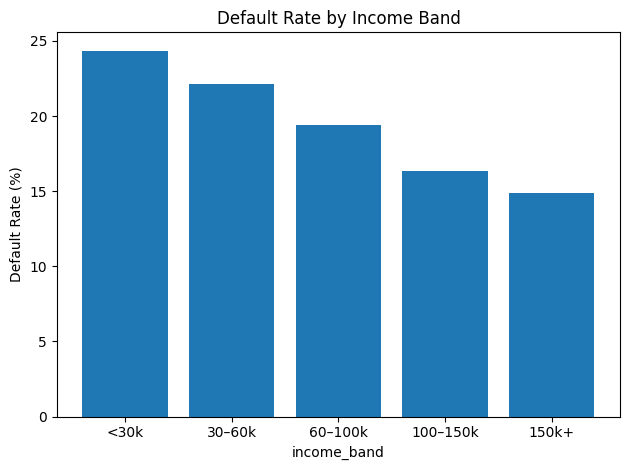

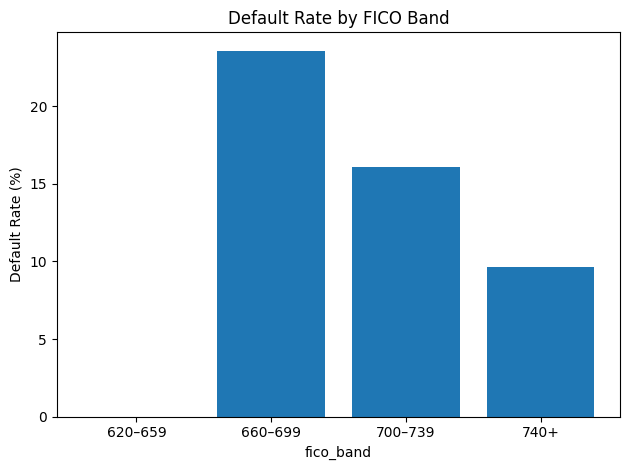

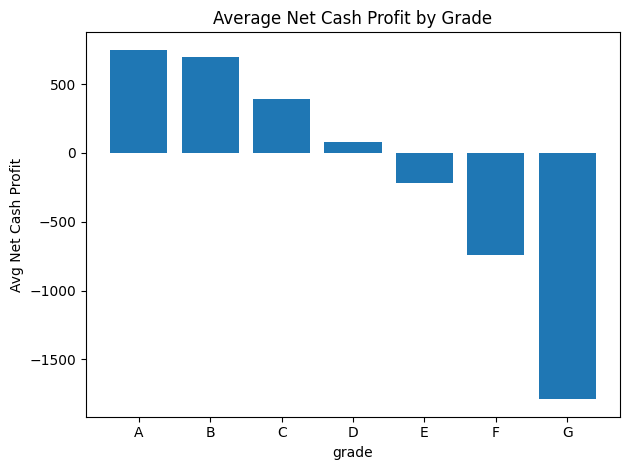

In [7]:
# 3) Default by grade
grade_df = results[2]["df"]
if "grade" in grade_df.columns and "default_rate_pct" in grade_df.columns:
    bar_plot(grade_df, "grade", "default_rate_pct", "Default Rate by Grade", ylabel="Default Rate (%)")

# 4) Default by sub_grade 
subgrade_df = results[3]["df"]
if "sub_grade" in subgrade_df.columns and "default_rate_pct" in subgrade_df.columns:
    bar_plot(subgrade_df, "sub_grade", "default_rate_pct", "Default Rate by Sub-Grade", ylabel="Default Rate (%)", rotate_x=True)

# Purpose 
for r in results:
    df = r["df"]
    if "purpose" in df.columns and "default_rate_pct" in df.columns:
        bar_plot(df, "purpose", "default_rate_pct", "Default Rate by Purpose", ylabel="Default Rate (%)", rotate_x=True)
        break

# Income band 
for r in results:
    df = r["df"]
    if "income_band" in df.columns and "default_rate_pct" in df.columns:
        bar_plot(df, "income_band", "default_rate_pct", "Default Rate by Income Band", ylabel="Default Rate (%)")
        break

# FICO band 
for r in results:
    df = r["df"]
    if "fico_band" in df.columns and "default_rate_pct" in df.columns:
        bar_plot(df, "fico_band", "default_rate_pct", "Default Rate by FICO Band", ylabel="Default Rate (%)")
        break

# Profit by grade
for r in results:
    df = r["df"]
    if "grade" in df.columns and "avg_net_cash_profit" in df.columns:
        bar_plot(df, "grade", "avg_net_cash_profit", "Average Net Cash Profit by Grade", ylabel="Avg Net Cash Profit")
        break

### Portfolio Size & Class Balance

The dataset contains **1.35 million accepted loans** with final outcomes only.
The observed **default rate is ~20%**, indicating a realistically imbalanced
credit-risk dataset.

This level of imbalance is typical in consumer lending and motivates:
- risk segmentation
- careful model evaluation (e.g. AUC, calibration)
- profit-aware decision-making rather than accuracy alone

### Basic Lending Characteristics

The average loan in the portfolio is approximately **£14.4k**, with an average
interest rate of **13.2%**.

Borrowers have:
- Average annual income of **£76k**
- Average DTI of **18%**
- Average FICO score close to **700**

Overall, this suggests a broadly mid-prime portfolio with meaningful variation
in borrower quality, suitable for risk segmentation analysis.

### Default Rate by Grade

Default rates increase **monotonically** from Grade A to G, confirming that
the lender’s grading system is strongly predictive of realised credit risk.

Key observations:
- Grade A defaults at ~6%
- Grade G defaults at ~50%
- Loan size and interest rate both increase with risk
- Average FICO declines steadily across grades

This validates grade as the primary risk control variable in the portfolio.


### Loan Term and Risk

60-month loans exhibit **double the default rate** of 36-month loans
(32% vs 16%), alongside:
- Larger average loan sizes
- Higher interest rates

This highlights loan term as a critical risk driver and a strong candidate
feature in predictive modelling.


### Loan Purpose and Risk

Loan purpose shows clear variation in default risk:
- Small business loans are the riskiest (~30%)
- Weddings and car loans are among the lowest risk
- Debt consolidation dominates the portfolio volume

Purpose is therefore a meaningful behavioural risk signal rather than noise.

### Portfolio-Level Profit Proxy

Using a simple cash-based proxy (total payments minus funded amount),
the portfolio generates:

- Average net profit per loan: **£412**
- Total net profit: **~£554m**
- Net return: **~2.9% of funded capital**

This provides a high-level view of portfolio performance.

In [2]:
"""
Credit Risk KPI Analysis
========================
Analyzes credit risk metrics from loan data and generates visualizations.

Usage:
    # In Jupyter Notebook:
    results = run_analysis()
    
    # Command line:
    python analyze_kpis.py
    python analyze_kpis.py --db path/to/db.db --sql path/to/queries.sql
    python analyze_kpis.py --output-dir ./reports --csv
"""

import sqlite3
import argparse
import sys
from pathlib import Path
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt


# Configuration
DEFAULT_DB_PATH = Path("credit_risk.db")
DEFAULT_SQL_PATH = Path("sql/kpi_queries.sql")
DEFAULT_OUTPUT_DIR = Path("output")


def parse_sql_file(sql_path: Path) -> List[Dict[str, str]]:
    """
    Parse SQL file into individual queries with their comment titles.
    
    Args:
        sql_path: Path to SQL file containing queries
        
    Returns:
        List of dicts with 'title' and 'query' keys
        
    Raises:
        FileNotFoundError: If SQL file doesn't exist
    """
    if not sql_path.exists():
        raise FileNotFoundError(f"SQL file not found: {sql_path}")
    
    content = sql_path.read_text(encoding="utf-8").splitlines()
    queries = []
    comments = []
    sql_lines = []
    
    def flush():
        nonlocal comments, sql_lines
        if sql_lines:
            queries.append({
                "title": " ".join(comments).strip(),
                "query": "\n".join(sql_lines).strip()
            })
        comments, sql_lines = [], []
    
    for line in content:
        stripped = line.strip()
        if not stripped:
            continue
        
        # Collect leading comments as title
        if stripped.startswith("--") and not sql_lines:
            comments.append(stripped[2:].strip())
            continue
        
        # Remove inline comments
        if "--" in line:
            line = line.split("--", 1)[0].rstrip()
        
        sql_lines.append(line)
        
        # Query complete when we hit semicolon
        if stripped.endswith(";"):
            flush()
    
    # Flush any remaining query
    if sql_lines:
        flush()
    
    return queries


def execute_queries(db_path: Path, queries: List[Dict[str, str]]) -> List[Dict[str, Any]]:
    """
    Execute SQL queries against database and return results.
    
    Args:
        db_path: Path to SQLite database
        queries: List of query dicts from parse_sql_file
        
    Returns:
        List of dicts with 'i', 'title', and 'df' keys
        
    Raises:
        FileNotFoundError: If database doesn't exist
        sqlite3.Error: If database connection fails
    """
    if not db_path.exists():
        raise FileNotFoundError(f"Database not found: {db_path}")
    
    results = []
    
    with sqlite3.connect(db_path) as conn:
        for i, q in enumerate(queries, 1):
            try:
                df = pd.read_sql_query(q["query"], conn)
                title = q["title"] or f"Query {i}"
                results.append({"i": i, "title": title, "df": df})
                print(f"✓ Executed: {title}")
            except Exception as e:
                print(f"✗ Failed query {i}: {e}", file=sys.stderr)
                continue
    
    return results


def print_results(results: List[Dict[str, Any]]) -> None:
    """Print query results to console."""
    for r in results:
        print(f"\n{'='*80}")
        print(f"KPI {r['i']}: {r['title']}")
        print('='*80)
        print(r["df"].to_string(index=False))


def save_results_csv(results: List[Dict[str, Any]], output_dir: Path) -> None:
    """
    Save query results as CSV files.
    
    Args:
        results: Query results from execute_queries
        output_dir: Directory to save CSV files
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for r in results:
        # Create safe filename from title
        safe_title = "".join(c if c.isalnum() or c in (' ', '_') else '_' 
                            for c in r['title'])
        safe_title = safe_title.replace(' ', '_').lower()
        filename = output_dir / f"kpi_{r['i']:02d}_{safe_title}.csv"
        
        r['df'].to_csv(filename, index=False)
        print(f"Saved: {filename}")


def bar_plot(df: pd.DataFrame, x: str, y: str, title: str, 
             xlabel: str = None, ylabel: str = None, 
             rotate_x: bool = False, output_path: Path = None) -> None:
    """
    Create and optionally save a bar plot.
    
    Args:
        df: DataFrame containing the data
        x: Column name for x-axis
        y: Column name for y-axis
        title: Plot title
        xlabel: X-axis label (defaults to x)
        ylabel: Y-axis label (defaults to y)
        rotate_x: Whether to rotate x-axis labels
        output_path: If provided, save plot to this path
    """
    plt.figure(figsize=(10, 6))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel or x, fontsize=12)
    plt.ylabel(ylabel or y, fontsize=12)
    
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved plot: {output_path}")
    else:
        plt.show()
    
    plt.close()


def generate_visualizations(results: List[Dict[str, Any]], 
                           output_dir: Path = None) -> None:
    """
    Generate all standard visualizations from query results.
    
    Args:
        results: Query results from execute_queries
        output_dir: If provided, save plots to this directory
    """
    if output_dir:
        output_dir.mkdir(parents=True, exist_ok=True)
    
    # Helper to find result by column presence
    def find_result(cols: List[str]) -> pd.DataFrame:
        for r in results:
            if all(col in r["df"].columns for col in cols):
                return r["df"]
        return None
    
    # 1. Default by grade
    df = find_result(["grade", "default_rate_pct"])
    if df is not None:
        output = output_dir / "default_by_grade.png" if output_dir else None
        bar_plot(df, "grade", "default_rate_pct", 
                "Default Rate by Grade", 
                ylabel="Default Rate (%)", 
                output_path=output)
    
    # 2. Default by sub-grade
    df = find_result(["sub_grade", "default_rate_pct"])
    if df is not None:
        output = output_dir / "default_by_subgrade.png" if output_dir else None
        bar_plot(df, "sub_grade", "default_rate_pct", 
                "Default Rate by Sub-Grade", 
                ylabel="Default Rate (%)", 
                rotate_x=True,
                output_path=output)
    
    # 3. Default by purpose
    df = find_result(["purpose", "default_rate_pct"])
    if df is not None:
        output = output_dir / "default_by_purpose.png" if output_dir else None
        bar_plot(df, "purpose", "default_rate_pct", 
                "Default Rate by Purpose", 
                ylabel="Default Rate (%)", 
                rotate_x=True,
                output_path=output)
    
    # 4. Default by income band
    df = find_result(["income_band", "default_rate_pct"])
    if df is not None:
        output = output_dir / "default_by_income.png" if output_dir else None
        bar_plot(df, "income_band", "default_rate_pct", 
                "Default Rate by Income Band", 
                ylabel="Default Rate (%)",
                output_path=output)
    
    # 5. Default by FICO band
    df = find_result(["fico_band", "default_rate_pct"])
    if df is not None:
        output = output_dir / "default_by_fico.png" if output_dir else None
        bar_plot(df, "fico_band", "default_rate_pct", 
                "Default Rate by FICO Band", 
                ylabel="Default Rate (%)",
                output_path=output)
    
    # 6. Profit by grade
    df = find_result(["grade", "avg_net_cash_profit"])
    if df is not None:
        output = output_dir / "profit_by_grade.png" if output_dir else None
        bar_plot(df, "grade", "avg_net_cash_profit", 
                "Average Net Cash Profit by Grade", 
                ylabel="Avg Net Cash Profit",
                output_path=output)


def run_analysis(db_path: Path = DEFAULT_DB_PATH,
                sql_path: Path = DEFAULT_SQL_PATH,
                output_dir: Optional[Path] = None,
                save_csv: bool = False,
                generate_viz: bool = True,
                print_output: bool = True) -> List[Dict[str, Any]]:
    """
    Main analysis function (Jupyter-friendly).
    
    Args:
        db_path: Path to SQLite database
        sql_path: Path to SQL queries file
        output_dir: Directory to save outputs (None = don't save)
        save_csv: Whether to save CSV files
        generate_viz: Whether to generate visualizations
        print_output: Whether to print results to console
        
    Returns:
        List of query results
    """
    print(f"{'='*80}")
    print("Credit Risk KPI Analysis")
    print(f"{'='*80}")
    print(f"Database: {db_path}")
    print(f"SQL File: {sql_path}")
    print(f"{'='*80}\n")
    
    # Parse SQL queries
    print("Parsing SQL queries...")
    queries = parse_sql_file(sql_path)
    print(f"Found {len(queries)} queries\n")
    
    # Execute queries
    print("Executing queries...")
    results = execute_queries(db_path, queries)
    print(f"\nCompleted {len(results)} queries\n")
    
    # Print results
    if print_output:
        print_results(results)
    
    # Save CSV if requested
    if save_csv and output_dir:
        print(f"\nSaving CSV files to {output_dir}...")
        save_results_csv(results, output_dir)
    
    # Generate visualizations
    if generate_viz:
        print("\nGenerating visualizations...")
        generate_visualizations(results, output_dir)
        print("\n✓ Visualization generation complete")
    
    print(f"\n{'='*80}")
    print("Analysis complete!")
    print(f"{'='*80}")
    
    return results


def main():
    """Main execution function for CLI usage."""
    # Check if running in Jupyter
    try:
        get_ipython()
        in_jupyter = True
    except NameError:
        in_jupyter = False
    
    if in_jupyter:
        # Running in Jupyter - use default behavior
        print("📓 Running in Jupyter environment")
        print("💡 Use: results = run_analysis()")
        print("💡 Or with options: results = run_analysis(output_dir=Path('reports'), save_csv=True)")
        return
    
    # Running from command line - parse arguments
    parser = argparse.ArgumentParser(
        description="Analyze credit risk KPIs from loan database",
        formatter_class=argparse.RawDescriptionHelpFormatter,
        epilog=__doc__
    )
    parser.add_argument(
        "--db", 
        type=Path, 
        default=DEFAULT_DB_PATH,
        help=f"Path to SQLite database (default: {DEFAULT_DB_PATH})"
    )
    parser.add_argument(
        "--sql", 
        type=Path, 
        default=DEFAULT_SQL_PATH,
        help=f"Path to SQL queries file (default: {DEFAULT_SQL_PATH})"
    )
    parser.add_argument(
        "--output-dir", 
        type=Path, 
        default=None,
        help="Save outputs to directory (creates if doesn't exist)"
    )
    parser.add_argument(
        "--no-viz", 
        action="store_true",
        help="Skip visualization generation"
    )
    parser.add_argument(
        "--csv", 
        action="store_true",
        help="Export results to CSV files"
    )
    
    args = parser.parse_args()
    
    try:
        run_analysis(
            db_path=args.db,
            sql_path=args.sql,
            output_dir=args.output_dir,
            save_csv=args.csv,
            generate_viz=not args.no_viz,
            print_output=True
        )
        
    except Exception as e:
        print(f"\n✗ Error: {e}", file=sys.stderr)
        sys.exit(1)


if __name__ == "__main__":
    main()

📓 Running in Jupyter environment
💡 Use: results = run_analysis()
💡 Or with options: results = run_analysis(output_dir=Path('reports'), save_csv=True)
